# Multi-Agent Systems: Supervisor

So far we have seen two types of agents: The ReAct agent and the Plan and Execute agent. Both agents are single agents that can solve complex tasks by breaking them down into smaller steps. However, some tasks are too complex for a single agent to handle. In such cases, we can use multiple agents that work together to solve the task. This is where multi-agent systems come into play.

When are tasks too complex for a single agent? There are several reasons why this might be the case:

- The execution becomes so long that the context window of th underlying LLM becomes a bottleneck.
- The agent has access to too many tools, making it difficult for a single agent to decide which tool to use.

A solution to both problems is to use multiple agents that work together to solve the task. Each agent can be specialized in a specific area, making it easier for the overall system to handle complex tasks. In a nutshell, each agent would handle one part of the context and a subset of the tools. The agents would then communicate with each other to solve the overall task. How they communicate is up to us. In this notebook, we will see the supervisor agent. The supervisor agent is a special agent that oversees the work of other agents. The supervisor agent will receive the user's input and decide which agent is best suited to handle the task. The supervisor agent will then delegate the task to the chosen agent and wait for the result. Once the result is received, the supervisor agent will send it back to the user.

## Imports, Environment, Chat Model, and Tools

As always, we start by importing the necessary libraries and setting up the environment.

In [2]:
import os
import dotenv
from typing import List
from IPython.display import Image
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langfuse.langchain import CallbackHandler

# Load environment variables from .env file.
dotenv.load_dotenv()

# Initialize the Langfuse handler
langfuse_handler = CallbackHandler()

# Initialize the chat model
model = init_chat_model(os.environ["LANGCHAIN_CHAT_MODEL_ANTHROPIC"])

Exception while exporting Span.
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.3.3/libexec/lib/python3.13/site-packages/urllib3/connection.py", line 199, in _new_conn
    sock = connection.create_connection(
        (self._dns_host, self.port),
    ...<2 lines>...
        socket_options=self.socket_options,
    )
  File "/opt/homebrew/Cellar/jupyterlab/4.3.3/libexec/lib/python3.13/site-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/opt/homebrew/Cellar/jupyterlab/4.3.3/libexec/lib/python3.13/site-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
    ~~~~~~~~~~~~^^^^
ConnectionRefusedError: [Errno 61] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/jupyterlab/4.3.3/libexec/lib/python3.13/site-packages/urllib3/connectionpool.py", line 789, in urlopen
    response = self._ma

Again we will use the Anthropic model, but you can use any model that is supported by LangChain and that is good at tool use.

And we will reuse the tools we have already created.

In [3]:
class MathToolInput(BaseModel):
    """Input for the math tool."""
    operand1: float = Field(..., description="The first operand for the math operation.")
    operand2: float = Field(..., description="The second operand for the math operation.")
    operator: str = Field(..., description="The operator for the math operation", enumerate=["+", "-", "*", "/"])

@tool
def math_tool(input: MathToolInput) -> float:
    """Perform a math operation based on the input."""
    if input.operator == "+":
        return input.operand1 + input.operand2
    elif input.operator == "-":
        return input.operand1 - input.operand2
    elif input.operator == "*":
        return input.operand1 * input.operand2
    elif input.operator == "/":
        if input.operand2 == 0:
            raise ValueError("Cannot divide by zero.")
        return input.operand1 / input.operand2
    else:
        raise ValueError(f"Unknown operator: {input.operator}")


class SortToolInput(BaseModel):
    """Input for the sort tool."""
    numbers: List[float] = Field(..., description="A list of numbers to sort.")
    order: str = Field(..., description="The order to sort the numbers", enumerate=["asc", "desc"])

@tool
def sort_tool(input: SortToolInput) -> List[float]:
    """Sort a list of numbers in ascending or descending order."""
    if input.order == "asc":
        return sorted(input.numbers)
    elif input.order == "desc":
        return sorted(input.numbers, reverse=True)
    else:
        raise ValueError(f"Unknown order: {input.order}")

/var/folders/x0/xs9r1crn50s7y70ntqd5wyvr0000gn/T/ipykernel_42363/2030071592.py:5: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'enumerate'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  operator: str = Field(..., description="The operator for the math operation", enumerate=["+", "-", "*", "/"])
/var/folders/x0/xs9r1crn50s7y70ntqd5wyvr0000gn/T/ipykernel_42363/2030071592.py:27: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'enumerate'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  order: str = Field(..., description="The order to sort the numbers", enumerate=["asc", "desc"])


## Creating two Agents

We will create two agents: One that will use the math tool and one that will use the web search tool. Both agents will be ReAct agents.

In [4]:
math_agent = create_react_agent(
    model=model,
    tools=[math_tool],
    prompt="You are a helpful assistant that can perform math operations.",
    name="math_agent"
)

sort_agent = create_react_agent(
    model=model,
    tools=[sort_tool],
    prompt="You are a helpful assistant that can sort numbers.",
    name="sort_agent"
)

/var/folders/x0/xs9r1crn50s7y70ntqd5wyvr0000gn/T/ipykernel_42363/2545575662.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  math_agent = create_react_agent(
/var/folders/x0/xs9r1crn50s7y70ntqd5wyvr0000gn/T/ipykernel_42363/2545575662.py:8: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  sort_agent = create_react_agent(


Here we see again, what an agent is. An agent is a combination of a chat model, a set of tools, and an agent prompt that tells the agent how to use the tools.

## Introducing the Supervisor Agent

So far these agents are independent of each other. They do not know about each other. They do not communicate with each other. They do not share any state. They are completely isolated from each other. So how do we facilitate multi-agent collaboration? We need a third agent that will oversee the work of the other two agents. This is the supervisor agent.

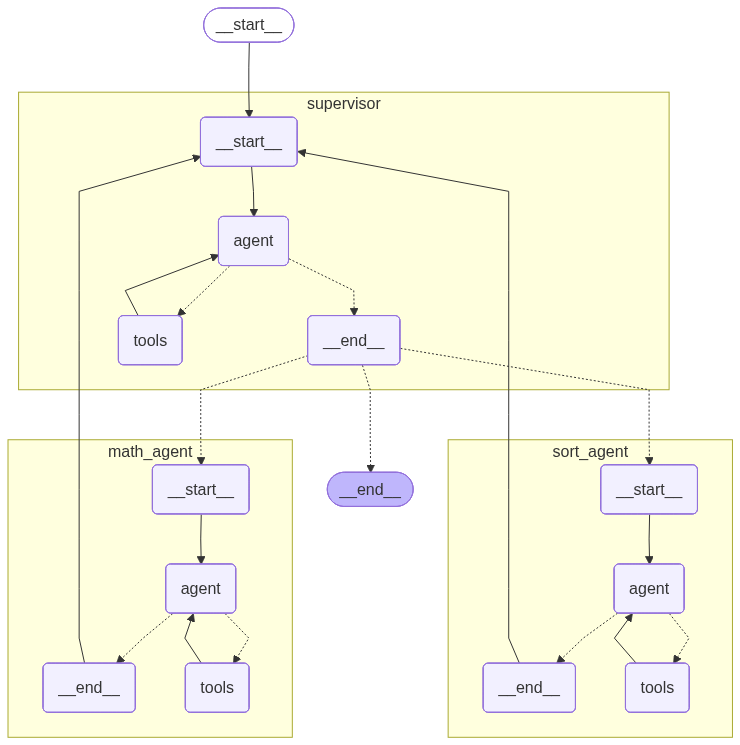

In [5]:
supervisor_agent = create_supervisor(
    model=model,
    agents=[math_agent, sort_agent],
    prompt="You are a supervisor that coordinates multiple agents to solve complex tasks. Delegate tasks to the appropriate agents based on their capabilities.",
).compile()

# Render the graph.
display(Image(supervisor_agent.get_graph(xray=True).draw_mermaid_png()))

We can now invoke the supervisor agent with a complex task that requires the use of both agents. The supervisor agent will decide which agent to use based on the task and delegate the task to the chosen agent. Once the chosen agent has completed the task, it will return the result to the supervisor agent, which will then return the result to the user.

In [6]:
print("Invoking supervisor...")
for chunk in supervisor_agent.stream({
    "messages": [HumanMessage(content="Find out the sum of 123456789 and 987654321, then sort the numbers 10, 5, 3, -24, 0 in descending order.")],
    },
    config={"callbacks": [langfuse_handler]},
):
    print(chunk)
    print("\n")

Invoking supervisor...
{'supervisor': {'messages': [HumanMessage(content='Find out the sum of 123456789 and 987654321, then sort the numbers 10, 5, 3, -24, 0 in descending order.', additional_kwargs={}, response_metadata={}, id='b99a14ae-8694-44bd-a6f5-386e1ec948ec'), AIMessage(content=[{'text': "I'll help you with both tasks. Let me delegate them to the appropriate agents.", 'type': 'text'}, {'id': 'toolu_01B5oebyqHtfELh4xqnATpYM', 'input': {'query': 'Find the sum of 123456789 and 987654321'}, 'name': 'transfer_to_math_agent', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_0199rk5ikJLyva2UmAo41N2d', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 457, 'output_tokens': 79, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-h

# Done.